─────────────────────────────────────────────────────────  
## **실습 — 회전기계 데이터셋 컬럼 매핑**  
─────────────────────────────────────────────────────────  

- 케이스 A : 1번 모터 - 베어링 손상 조기 경보
- 케이스 B : 1번 팬 - 분진 축적에 따른 불평형 감지


In [1]:
import os
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", None)


### 데이터 불러오기

태그 목록은 설비별 보유 신호를 확인하는 데 사용하고, 진동 추세 데이터는 실제 컬럼 존재 여부와 신호 변화 확인에 사용한다.


In [2]:
tags_path = os.path.join("..", "Data", "03-01_회전기계_신호_회전기계태그목록.csv")
df_path = os.path.join("..", "Data", "03-01_회전기계_신호_진동추세.csv")

tags = pd.read_csv(tags_path, encoding="utf-8")
df = pd.read_csv(df_path, encoding="utf-8")

df.head()


,date,MTR01_VIB_H,MTR01_VIB_V,MTR01_VIB_A,MTR01_VIB_ACC,MTR01_CURRENT,MTR01_TEMP,MTR01_RPM,PMP01_VIB_H,PMP01_VIB_V,PMP01_VIB_A,PMP01_VIB_ACC
0,2026-01-01,1.8,1.4,0.7,0.52,62.5,48.0,1780,2.1,1.6,0.9,0.61
1,2026-01-02,1.9,1.5,0.7,0.54,63.0,48.0,1780,2.0,1.7,0.9,0.60
2,2026-01-03,1.8,1.4,0.8,0.53,62.0,48.5,1780,2.2,1.6,1.0,0.62
3,2026-01-04,2.0,1.5,0.7,0.55,64.0,48.5,1780,2.1,1.7,0.9,0.61
4,2026-01-05,1.9,1.5,0.8,0.54,63.5,49.0,1780,2.0,1.6,1.0,0.63


## CASE A — 1번 모터, 베어링 손상 조기 경보

### Step 1. 고장 유형과 물리량 도출

목표 고장 유형 : 1번 모터 - 베어링 손상 조기 경보  
진행 속도 (빠름 / 느림) : 느림

| 구분 | 물리량 | 그 물리량을 고른 이유 |
|---|---|---|
| 주 신호 | 진동 | 베어링 손상은 초기 충격성 진동 변화로 먼저 나타남 |
| 확인 신호 1 | 온도 | 손상 진행 시 마찰 증가로 베어링 온도가 상승할 수 있음 |
| 확인 신호 2 | 전류 | 부하 증가나 회전 저항 증가 시 모터 전류가 변할 수 있음 |


In [3]:
mtr_cols = list(df.columns[df.columns.str.startswith("MTR01")])
mtr_tags = tags[tags["equipment"] == "1번 모터"]

print("1번 모터 추세 데이터 컬럼:", mtr_cols)
display(mtr_tags)


1번 모터 추세 데이터 컬럼: ['MTR01_VIB_H', 'MTR01_VIB_V', 'MTR01_VIB_A', 'MTR01_VIB_ACC', 'MTR01_CURRENT', 'MTR01_TEMP', 'MTR01_RPM']


,tag,equipment,physical_qty,indicator,summary,unit,direction,install_location
0,MTR01_VIB_H,1번 모터,진동,속도,RMS,mm/s,수평,구동측 베어링 하우징
1,MTR01_VIB_V,1번 모터,진동,속도,RMS,mm/s,수직,구동측 베어링 하우징
2,MTR01_VIB_A,1번 모터,진동,속도,RMS,mm/s,축방향,구동측 베어링 하우징
3,MTR01_VIB_ACC,1번 모터,진동,가속도,PEAK,g,수평,구동측 베어링 하우징
4,MTR01_CURRENT,1번 모터,전류,전류,순시값,A,해당없음,모터 제어반 전류 변성기
5,MTR01_TEMP,1번 모터,온도,온도,순시값,degC,해당없음,구동측 베어링 매입 측온저항체
6,MTR01_RPM,1번 모터,회전수,회전수,순시값,rpm,해당없음,축 단부 회전수 센서


### Step 2. 지표·요약 방식·위치·주기 결정

주 신호 지표 (변위/속도/가속도) : 가속도  
이유: 베어링 초기 손상은 충격성 성분이므로 가속도 신호가 조기 감지에 유리함

요약 방식 (RMS/PEAK) : PEAK  
이유: 초기 결함은 순간 충격으로 나타나므로 최대값 기반 지표가 적합함

측정 위치 : 구동측 베어링 하우징  
측정 방향 : 수평  
필요 저장 주기 : 짧은 주기  
이유: 조기 경보 목적이므로 진동 신호 변화를 빠르게 확인해야 함


In [4]:
normal = df.head(20)

def first_over(col):
    limit = normal[col].max()
    over = df.index[df[col] > limit]
    return int(over[0]) + 1 if len(over) else None

for col in mtr_cols:
    row_no = first_over(col)
    result = f"{row_no}번째 행" if row_no is not None else "초과 없음"
    print(f"{col}값 중 정상 범위 초과: {result}")


MTR01_VIB_H값 중 정상 범위 초과: 39번째 행
MTR01_VIB_V값 중 정상 범위 초과: 44번째 행
MTR01_VIB_A값 중 정상 범위 초과: 초과 없음
MTR01_VIB_ACC값 중 정상 범위 초과: 22번째 행
MTR01_CURRENT값 중 정상 범위 초과: 49번째 행
MTR01_TEMP값 중 정상 범위 초과: 53번째 행
MTR01_RPM값 중 정상 범위 초과: 초과 없음


<Axes: xlabel='date'>

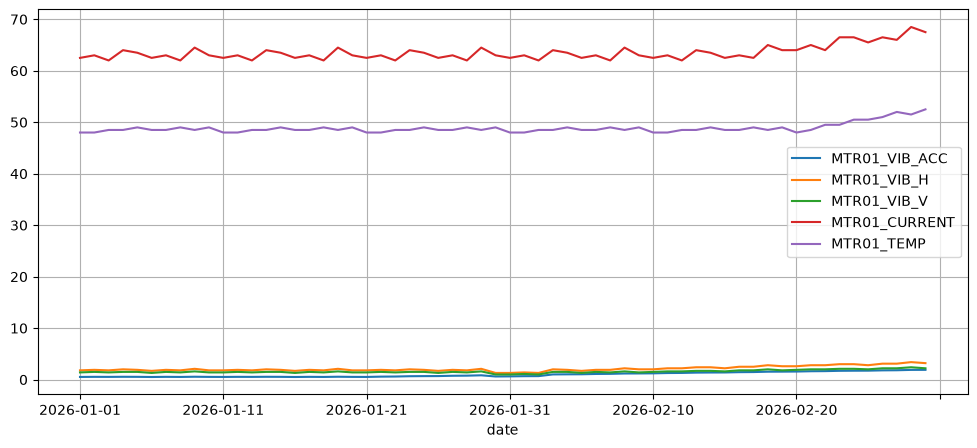

In [5]:
df[[
    "date",
    "MTR01_VIB_ACC", "MTR01_VIB_H", "MTR01_VIB_V", "MTR01_CURRENT", "MTR01_TEMP"
]].plot(
    x="date",
    figsize=(12, 5),
    grid=True
)


### Step 3. 보유 컬럼과 대조

| 필요 컬럼 | 보유 여부(O/X) | 실제 태그명 |
|---|---|---|
| 모터 진동 가속도 PEAK | O | MTR01_VIB_ACC |
| 모터 진동 속도 RMS | O | MTR01_VIB_H |
| 모터 베어링 온도 | O | MTR01_TEMP |
| 모터 전류 | O | MTR01_CURRENT |
| 모터 회전수 | O | MTR01_RPM |


## CASE B — 1번 팬, 분진 축적에 따른 불평형 감지

### Step 1. 고장 유형과 물리량 도출

목표 고장 유형 : 1번 팬 - 분진 축적에 따른 불평형 감지  
진행 속도 (빠름 / 느림) : 느림

| 구분 | 물리량 | 그 물리량을 고른 이유 |
|---|---|---|
| 주 신호 | 진동 | 팬에 분진이 쌓이면 회전체 질량 불균형으로 진동이 증가함 |
| 확인 신호 1 | 전류 | 불평형으로 회전 부하가 증가하면 팬 모터 전류가 변할 수 있음 |
| 확인 신호 2 | 온도 | 진동과 부하 증가가 지속되면 베어링 또는 모터 온도가 상승할 수 있음 |


In [6]:
fan_cols = list(df.columns[df.columns.str.startswith("FAN01")])
fan_tags = tags[tags["equipment"] == "1번 팬"]

print("1번 팬 추세 데이터 컬럼:", fan_cols)
display(fan_tags)


1번 팬 추세 데이터 컬럼: []


,tag,equipment,physical_qty,indicator,summary,unit,direction,install_location
14,FAN01_VIB_H,1번 팬,진동,속도,RMS,mm/s,수평,구동측 베어링 하우징
15,FAN01_CURRENT,1번 팬,전류,전류,순시값,A,해당없음,팬 제어반 전류 변성기
16,FAN01_TEMP,1번 팬,온도,온도,순시값,degC,해당없음,구동측 베어링 표면


### Step 2. 지표·요약 방식·위치·주기 결정

주 신호 지표 (변위/속도/가속도) : 속도  
이유: 불평형은 회전 주파수 성분의 지속적인 진동 증가로 나타나며, 설비 상태 감시에 진동 속도 RMS가 적합함

요약 방식 (RMS/PEAK) : RMS  
이유: 분진 축적에 따른 불평형은 순간 충격보다 지속적인 진동 증가로 나타남

측정 위치 : 구동측 베어링 하우징  
측정 방향 : 수평  
필요 저장 주기 : 중간 주기  
이유: 분진 축적은 점진적으로 진행되므로 추세 변화를 주기적으로 확인하면 됨


In [7]:
required_fan_tags = ["FAN01_VIB_H", "FAN01_CURRENT", "FAN01_TEMP", "FAN01_VIB_ACC", "FAN01_RPM"]

pd.DataFrame({
    "필요 태그": required_fan_tags,
    "태그목록 보유 여부": [tag in set(tags["tag"]) for tag in required_fan_tags],
    "추세데이터 보유 여부": [tag in set(df.columns) for tag in required_fan_tags],
})


,필요 태그,태그목록 보유 여부,추세데이터 보유 여부
0,FAN01_VIB_H,True,False
1,FAN01_CURRENT,True,False
2,FAN01_TEMP,True,False
3,FAN01_VIB_ACC,False,False
4,FAN01_RPM,False,False


### Step 3. 보유 컬럼과 대조

| 필요 컬럼 | 보유 여부(O/X) | 실제 태그명 |
|---|---|---|
| 팬 진동 속도 RMS | O | FAN01_VIB_H |
| 팬 전류 | O | FAN01_CURRENT |
| 팬 온도 | O | FAN01_TEMP |
| 팬 진동 가속도 PEAK | X | 없음 |
| 팬 회전수 | X | 없음 |
